# 11 — Depth / Threshold and Min-Cluster-Size Sensitivity

```text
Reviewer concern addressed: R1-b ("enrichment depends on dendrogram cut; comment on
    stability...across settings") and R2-b/R2-c/R2-d ("how is depth formally defined and
    selected?"; merge algorithm undocumented; min cluster size and its effect unspecified).
    Implements frozen-plan Phase 2 notebook 11 (with 12's min-cluster-size scope folded in,
    per the frozen plan's explicit instruction), the second of four Go/No-Go-checkpoint
    inputs (10, 11, 20, 21).
Input files: data/yeast/gi_pcc_sampled.tsv, data/yeast/go_bp_name_to_orfs.json
    (hashes cross-checked against 00_environment_check_manifest.json)
HiMaLAYAS version: verified git tag v0.0.15, activated via
    revision_utils.activate_pinned_source() -- the same pattern 01 and 10 established.
Random seed: none required. Threshold/min-cluster-size sweeps are deterministic given a
    fixed matrix (no noise, no permutation); this notebook introduces no stochastic step.
Primary parameters: reference clustering/enrichment config reproduced verbatim from
    fig_1.ipynb (linkage_method="ward", linkage_metric="euclidean", linkage_threshold=16,
    optimal_ordering=True, min_cluster_size=30, min_overlap=2, qval<=0.05). Threshold and
    min_cluster_size grids are calibrated from the actual dendrogram merge-height
    distribution (Section 6), not arbitrary round numbers.
Outputs written:
    revision/outputs/manifests/11_depth_threshold_sensitivity_manifest.json
    revision/outputs/tables/11_depth_threshold_sensitivity/*.csv
    revision/outputs/figures/11_depth_threshold_sensitivity/*.png
Interpretation: see the GO / CONDITIONAL GO / CONCERN decision in the final section.
```

## Design

Two independent 1-D sweeps, each holding the other parameter at its fig_1.ipynb reference
value:

1. **Threshold sweep**: vary `linkage_threshold` around 16, holding `min_cluster_size=30`.
2. **Min-cluster-size sweep**: vary `min_cluster_size` around 30, holding
   `linkage_threshold=16`.

Each grid point is reclustered and re-enriched from scratch, then every reference cluster is
matched to its best gene-membership-overlap cluster at that setting (same
`revision_utils.match_clusters_by_membership` Jaccard-matching approach notebook 10 used for
noise replicates), and we check whether the reference cluster's headline (top) annotation
survives at q<=0.05 in the matched cluster. A cluster is flagged **knife-edge** if retention
flips between the reference setting and either adjacent grid point -- i.e. the conclusion
depends on one specific, narrow setting rather than holding across a band.

## 1. Locate repo root and import shared revision utilities

In [1]:
import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    markers = ("himalayas_src", "data", ".git", "revision")
    for candidate in (start, *start.parents):
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise RuntimeError(f"Could not locate himalayas-publication repo root above {start}")


REPO_ROOT = _find_repo_root(Path.cwd().resolve())
SRC_DIR = REPO_ROOT / "revision" / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print(f"Kernel CWD:  {Path.cwd()}")
print(f"Repo root:   {REPO_ROOT}")

Kernel CWD:  /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/notebooks
Repo root:   /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication


In [2]:
import json
import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd

import revision_utils as ru
from revision_utils import DEFAULT_RANDOM_SEED, revision_layout

layout = revision_layout(REPO_ROOT)
for key in ("manifests_dir", "figures_dir", "tables_dir", "scratch_dir"):
    layout[key].mkdir(parents=True, exist_ok=True)

NB_ID = "11_depth_threshold_sensitivity"
NB_FIGURES_DIR = layout["figures_dir"] / NB_ID
NB_TABLES_DIR = layout["tables_dir"] / NB_ID
NB_SCRATCH_DIR = layout["scratch_dir"] / NB_ID
for d in (NB_FIGURES_DIR, NB_TABLES_DIR, NB_SCRATCH_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Figures ->", NB_FIGURES_DIR)
print("Tables  ->", NB_TABLES_DIR)
print("Scratch ->", NB_SCRATCH_DIR)

Figures -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/figures/11_depth_threshold_sensitivity
Tables  -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/tables/11_depth_threshold_sensitivity
Scratch -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/11_depth_threshold_sensitivity


## 2. Recall notebooks 00/01/10 findings

In [3]:
nb00_manifest = ru.read_manifest(layout["manifests_dir"] / "00_environment_check_manifest.json")
nb01_manifest = ru.read_manifest(
    layout["manifests_dir"] / "01_reproduce_submitted_figures_manifest.json"
)
nb10_manifest = ru.read_manifest(
    layout["manifests_dir"] / "10_noise_robustness_gi_pcc_manifest.json"
)

print("00_environment_check flags:")
for f in nb00_manifest["flags"]:
    print(f"  - {f}")
print()
print(
    f"10_noise_robustness_gi_pcc: status={nb10_manifest['status']} decision={nb10_manifest['decision']}"
)
print(f"  next_action: {nb10_manifest['next_action']}")

himalayas_diag_before = ru.himalayas_diagnostics(layout["repo_root"])
print()
print(
    f"Active kernel HiMaLAYAS (before activation below): {himalayas_diag_before['imported_version']} "
    f"(editable={himalayas_diag_before['is_editable_install']})"
)

00_environment_check flags:
  - ACTIVE HiMaLAYAS VERSION MISMATCH: kernel imports '0.0.16a0' but README pins '0.0.15'.
  - EDITABLE HiMaLAYAS SOURCE IS DIRTY: /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas has 5 uncommitted path(s): ['M src/himalayas/__init__.py', '?? PREVIEW_NOTES.md', '?? _archive/', '?? preview-release-notes.sh', '?? test.py'].
  - EDITABLE HiMaLAYAS SOURCE IS AHEAD OF ITS LAST TAG: git describe = 'v0.0.15-4-g0c51115'.
  - VENDORED COPY VERSION DIFFERS FROM IMPORTED VERSION: himalayas_src/ declares '0.0.15', kernel imports '0.0.16a0'.
  - PUBLICATION REPO HAS UNCOMMITTED/UNTRACKED PATHS: 6 path(s) -- expected during active revision work (e.g. this new revision/ tree itself); noted for provenance only.

10_noise_robustness_gi_pcc: status=COMPLETE decision=GO
  next_action: Proceed to 11_depth_threshold_sensitivity.ipynb. Headline functional annotations (7/7 reference clusters) are robust to moderate matrix perturbation


Active kernel HiMaLAYAS (before activation below): 0.0.16a0 (editable=True)


## 3. Activate the verified pinned v0.0.15 source

Same pattern notebook 10 established: the active editable install may be an unreleased dev version, so any result reported here runs under the verified tag instead.

In [4]:
PINNED_TAG = "v0.0.15"

try:
    activation = ru.activate_pinned_source(
        layout["repo_root"], NB_SCRATCH_DIR / "himalayas_pinned_v0_0_15", tag=PINNED_TAG
    )
    activation_error = None
except RuntimeError as exc:
    activation = None
    activation_error = str(exc)

if activation is not None:
    print(json.dumps(activation, indent=2))
else:
    print(f"ACTIVATION FAILED: {activation_error}")

import himalayas
from himalayas import Analysis, Annotations, Matrix
from himalayas.core.clustering import compute_linkage, cut_linkage

print()
print(f"himalayas module now bound to: {himalayas.__file__}")
print(f"himalayas.__version__:         {himalayas.__version__}")

if activation is not None:
    assert (
        himalayas.__version__ == "0.0.15"
    ), f"Expected pinned v0.0.15 after activation, got {himalayas.__version__!r}"
    assert activation["matches_requested_tag"], "activate_pinned_source reported a version mismatch"
    print("\nConfirmed: this notebook's HiMaLAYAS analyses run under verified tag v0.0.15.")

{
  "requested_tag": "v0.0.15",
  "sibling_repo": "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas",
  "pinned_src_dir": "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/11_depth_threshold_sensitivity/himalayas_pinned_v0_0_15/src",
  "activated_version": "0.0.15",
  "activated_file": "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/11_depth_threshold_sensitivity/himalayas_pinned_v0_0_15/src/himalayas/__init__.py",
  "matches_requested_tag": true
}

himalayas module now bound to: /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/11_depth_threshold_sensitivity/himalayas_pinned_v0_0_15/src/himalayas/__init__.py
himalayas.__version__:         0.0.15

Confirmed: this notebook's HiMaLAYAS analyses run under verified tag

## 4. Load inputs and cross-check hashes against notebook 00

In [5]:
GI_PCC_PATH = layout["repo_root"] / "data" / "yeast" / "gi_pcc_sampled.tsv"
GO_BP_PATH = layout["repo_root"] / "data" / "yeast" / "go_bp_name_to_orfs.json"

current_hashes = {
    "data/yeast/gi_pcc_sampled.tsv": ru.sha256_file(GI_PCC_PATH),
    "data/yeast/go_bp_name_to_orfs.json": ru.sha256_file(GO_BP_PATH),
}
recorded_hashes = {r["path"]: r["sha256"] for r in nb00_manifest["input_files"]}

input_hash_flags = []
for rel_path, current_hash in current_hashes.items():
    recorded_hash = recorded_hashes.get(rel_path)
    matches = current_hash == recorded_hash
    print(f"{rel_path}: matches 00_environment_check record = {matches}")
    if not matches:
        input_hash_flags.append(
            f"INPUT HASH MISMATCH: {rel_path} changed since 00_environment_check ran "
            f"(recorded {recorded_hash}, now {current_hash})."
        )

DF_GI_PCC = pd.read_csv(GI_PCC_PATH, sep="\t", index_col=0)
with open(GO_BP_PATH, "r", encoding="utf-8") as fh:
    go_bp = json.load(fh)

print()
print(f"Matrix shape: {DF_GI_PCC.shape}")
print(f"GO BP terms loaded: {len(go_bp):,}")

data/yeast/gi_pcc_sampled.tsv: matches 00_environment_check record = True
data/yeast/go_bp_name_to_orfs.json: matches 00_environment_check record = True



Matrix shape: (1053, 1053)
GO BP terms loaded: 1,095


## 5. Reference analysis (threshold=16, min_cluster_size=30)

Reproduces fig_1.ipynb's exact configuration and cross-checks against notebooks 01/10's recorded reproduction (709 / 331 / 7).

In [6]:
REFERENCE_THRESHOLD = 16
REFERENCE_MIN_SIZE = 30
LINKAGE_METHOD = "ward"
LINKAGE_METRIC = "euclidean"
OPTIMAL_ORDERING = True
MIN_OVERLAP = 2
QVAL_CUTOFF = 0.05


def run_analysis(*, linkage_threshold, min_cluster_size):
    """Cluster + enrich the (unperturbed) GI-PCC matrix at one (threshold, min_size)
    setting and return (analysis, results, results_sig)."""
    with warnings.catch_warnings():
        warnings.simplefilter(
            "ignore", RuntimeWarning
        )  # expected: GO terms outside matrix universe
        matrix = Matrix(DF_GI_PCC)
        annotations = Annotations(go_bp, matrix)
        analysis = (
            Analysis(matrix, annotations)
            .cluster(
                linkage_method=LINKAGE_METHOD,
                linkage_metric=LINKAGE_METRIC,
                linkage_threshold=linkage_threshold,
                optimal_ordering=OPTIMAL_ORDERING,
                min_cluster_size=min_cluster_size,
            )
            .enrich(min_overlap=MIN_OVERLAP)
            .finalize(col_cluster=False)
        )
    results = analysis.results
    results_sig = results.filter(f"qval <= {QVAL_CUTOFF}")
    return analysis, results, results_sig


reference_analysis, reference_results, reference_results_sig = run_analysis(
    linkage_threshold=REFERENCE_THRESHOLD, min_cluster_size=REFERENCE_MIN_SIZE
)
reference_cluster_labels = reference_results_sig.cluster_labels(rank_by="p", label_mode="top_term")
reference_cluster_to_labels = {
    int(cid): set(genes) for cid, genes in reference_analysis.clusters.cluster_to_labels.items()
}
reference_term_sets = ru.cluster_term_sets(reference_results_sig.df)
reference_global_sig_terms = set(reference_results_sig.df["term"])
reference_top_term_by_cluster = dict(
    zip(reference_cluster_labels["cluster"], reference_cluster_labels["term"])
)

print(
    f"Reference: {len(reference_results.df)} enriched rows, "
    f"{len(reference_results_sig.df)} significant (q<={QVAL_CUTOFF}), "
    f"{len(reference_cluster_labels)} labeled clusters"
)

expected = nb10_manifest["reference_reproduction_check"]
reproduction_matches = (
    len(reference_results.df) == expected["results_rows"]
    and len(reference_results_sig.df) == expected["results_sig_rows"]
    and len(reference_cluster_labels) == expected["n_clusters"]
)
print(
    f"Matches notebooks 01/10's recorded fig_1.ipynb baseline (709/331/7): {reproduction_matches}"
)
assert (
    reproduction_matches
), "Reference analysis does not match the notebook-01/10 baseline -- stop and investigate"

reference_cluster_labels

Reference: 709 enriched rows, 331 significant (q<=0.05), 7 labeled clusters
Matches notebooks 01/10's recorded fig_1.ipynb baseline (709/331/7): True


,cluster,label,pval,qval,score,n,term,fe
0,1,GPI anchor biosynthetic process,3.222730e-12,8.788137e-11,3.222730e-12,148,GPI anchor biosynthetic process,5.568155
1,2,vesicle-mediated transport,1.237408e-26,4.386613e-24,1.237408e-26,92,vesicle-mediated transport,7.868886
2,3,"mRNA splicing, via spliceosome",2.829998e-16,1.433192e-14,2.829998e-16,263,"mRNA splicing, via spliceosome",3.745492
3,4,cytoplasmic translation,8.925220e-15,3.954988e-13,8.925220e-15,358,cytoplasmic translation,2.852209
4,5,mitochondrial respiratory chain complex IV ass...,1.794876e-19,1.590709e-17,1.794876e-19,78,mitochondrial respiratory chain complex IV ass...,12.750000
5,6,DNA replication,1.798541e-42,1.275166e-39,1.798541e-42,52,DNA replication,16.011628
6,7,cell division,2.138848e-20,2.707850e-18,2.138848e-20,62,cell division,8.177419


## 6. Dendrogram merge-height landscape

Grids are calibrated from the linkage tree's actual merge heights near the reference threshold, not arbitrary round numbers -- this identifies exactly which threshold values cross a real structural transition versus which sit in the same no-op band as the reference.

In [7]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    _reference_matrix_for_linkage = Matrix(DF_GI_PCC)
LINKAGE_MATRIX = compute_linkage(
    _reference_matrix_for_linkage,
    linkage_method=LINKAGE_METHOD,
    linkage_metric=LINKAGE_METRIC,
    optimal_ordering=OPTIMAL_ORDERING,
)
merge_heights = np.sort(LINKAGE_MATRIX[:, 2])
nearby_heights = merge_heights[(merge_heights >= 8) & (merge_heights <= 26)]
print(f"Merge heights within [8, 26] (reference threshold={REFERENCE_THRESHOLD}):")
print(np.round(nearby_heights, 3).tolist())

next_merge_above_reference = merge_heights[merge_heights > REFERENCE_THRESHOLD].min()
prev_merge_below_reference = merge_heights[merge_heights < REFERENCE_THRESHOLD].max()
print(
    f"\nReference threshold {REFERENCE_THRESHOLD} sits in the stable band "
    f"({prev_merge_below_reference:.3f}, {next_merge_above_reference:.3f}) -- "
    f"{next_merge_above_reference - REFERENCE_THRESHOLD:.3f} units below the next merge."
)

# Natural cluster count at each threshold (before min-cluster-size enforcement), for context.
scan_thresholds = list(range(8, 32))
natural_counts = []
for t in scan_thresholds:
    c = cut_linkage(LINKAGE_MATRIX, _reference_matrix_for_linkage.labels, t, min_cluster_size=1)
    natural_counts.append(len(c.unique_clusters))
pd.DataFrame({"threshold": scan_thresholds, "natural_n_clusters": natural_counts})

Merge heights within [8, 26] (reference threshold=16):
[8.301, 9.309, 9.515, 9.83, 9.917, 10.931, 11.526, 12.105, 13.442, 14.289, 14.341, 14.635, 16.358, 18.594, 19.344, 20.731, 23.358]

Reference threshold 16 sits in the stable band (14.635, 16.358) -- 0.358 units below the next merge.


,threshold,natural_n_clusters
0,8,19
1,9,18
2,10,14
3,11,13
4,12,12
5,13,11
6,14,10
7,15,7
8,16,7
9,17,6


## 7. Sweep grids

Threshold grid spans natural cluster counts from 8 down to 3, straddling every merge transition visible in Section 6. Min-cluster-size grid spans below the smallest natural reference cluster (52 genes) up past it, since enforcement is a no-op until `min_cluster_size` exceeds the smallest existing cluster.

In [8]:
THRESHOLD_GRID = [12, 14, 15, REFERENCE_THRESHOLD, 17, 18, 20, 22]
MIN_SIZE_GRID = [5, 10, 15, 20, 25, REFERENCE_MIN_SIZE, 40, 50, 60, 75, 100]
KNIFE_EDGE_NEIGHBORS = {
    "threshold": (15, 17),  # grid points immediately adjacent to REFERENCE_THRESHOLD=16
    "min_cluster_size": (25, 40),  # grid points immediately adjacent to REFERENCE_MIN_SIZE=30
}

print(f"Threshold grid (min_cluster_size fixed at {REFERENCE_MIN_SIZE}): {THRESHOLD_GRID}")
print(f"Min-cluster-size grid (threshold fixed at {REFERENCE_THRESHOLD}): {MIN_SIZE_GRID}")
print(f"Knife-edge neighbor points: {KNIFE_EDGE_NEIGHBORS}")

Threshold grid (min_cluster_size fixed at 30): [12, 14, 15, 16, 17, 18, 20, 22]
Min-cluster-size grid (threshold fixed at 16): [5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100]
Knife-edge neighbor points: {'threshold': (15, 17), 'min_cluster_size': (25, 40)}


## 8. Sweep execution

For each grid point on each axis: recluster + re-enrich, match every reference cluster to its best gene-membership-overlap cluster at that setting, and record whether the reference cluster's headline term survives at q<=0.05 in the matched cluster.

In [9]:
def sweep_one_setting(*, linkage_threshold, min_cluster_size):
    """Run one grid point and return (cluster-level rows, global-level row, cluster_to_labels,
    term_sets) for downstream merge-artifact inspection."""
    analysis, results, results_sig = run_analysis(
        linkage_threshold=linkage_threshold, min_cluster_size=min_cluster_size
    )
    cluster_to_labels = {
        int(cid): set(genes) for cid, genes in analysis.clusters.cluster_to_labels.items()
    }
    term_sets = ru.cluster_term_sets(results_sig.df)
    global_sig_terms = set(results_sig.df["term"])
    cluster_labels_df = results_sig.cluster_labels(rank_by="p", label_mode="top_term")
    top_term_by_cluster = dict(zip(cluster_labels_df["cluster"], cluster_labels_df["term"]))

    matches = ru.match_clusters_by_membership(reference_cluster_to_labels, cluster_to_labels)

    cluster_rows = []
    for ref_cid, match in matches.items():
        matched_cid = match["matched_cluster_id"]
        ref_terms = reference_term_sets.get(ref_cid, set())
        matched_terms = term_sets.get(matched_cid, set()) if matched_cid is not None else set()
        ref_top_term = reference_top_term_by_cluster.get(ref_cid)
        cluster_rows.append(
            {
                "ref_cluster_id": ref_cid,
                "ref_top_term": ref_top_term,
                "ref_n_genes": len(reference_cluster_to_labels[ref_cid]),
                "matched_cluster_id": matched_cid,
                "matched_n_genes": (
                    len(cluster_to_labels.get(matched_cid, set())) if matched_cid is not None else 0
                ),
                "membership_jaccard": match["membership_jaccard"],
                "cluster_term_jaccard": ru.jaccard(ref_terms, matched_terms),
                "top_term_retained": bool(ref_top_term in matched_terms),
                "top_term_present_globally": bool(ref_top_term in global_sig_terms),
                "matched_top_term": top_term_by_cluster.get(matched_cid),
            }
        )

    global_row = {
        "n_clusters": len(analysis.clusters.unique_clusters),
        "sig_rows": len(results_sig.df),
        "global_sig_term_jaccard": ru.jaccard(reference_global_sig_terms, global_sig_terms),
    }
    return cluster_rows, global_row, cluster_to_labels, term_sets, top_term_by_cluster


threshold_cluster_rows, threshold_global_rows = [], []
threshold_cluster_to_labels_by_value = {}
threshold_term_sets_by_value = {}
threshold_top_term_by_value = {}
for thr in THRESHOLD_GRID:
    cluster_rows, global_row, c2l, tsets, ttbc = sweep_one_setting(
        linkage_threshold=thr, min_cluster_size=REFERENCE_MIN_SIZE
    )
    for row in cluster_rows:
        row["threshold"] = thr
    threshold_cluster_rows.extend(cluster_rows)
    global_row["threshold"] = thr
    threshold_global_rows.append(global_row)
    threshold_cluster_to_labels_by_value[thr] = c2l
    threshold_term_sets_by_value[thr] = tsets
    threshold_top_term_by_value[thr] = ttbc
    retained = sum(r["top_term_retained"] for r in cluster_rows)
    print(
        f"threshold={thr:5.1f}  n_clusters={global_row['n_clusters']}  "
        f"sig_rows={global_row['sig_rows']:4d}  top-term retained={retained}/{len(cluster_rows)}"
    )

per_threshold_cluster_raw = pd.DataFrame(threshold_cluster_rows)
per_threshold_global_raw = pd.DataFrame(threshold_global_rows)

threshold= 12.0  n_clusters=8  sig_rows= 340  top-term retained=6/7


threshold= 14.0  n_clusters=8  sig_rows= 340  top-term retained=6/7


threshold= 15.0  n_clusters=7  sig_rows= 331  top-term retained=7/7


threshold= 16.0  n_clusters=7  sig_rows= 331  top-term retained=7/7


threshold= 17.0  n_clusters=6  sig_rows= 312  top-term retained=7/7


threshold= 18.0  n_clusters=6  sig_rows= 312  top-term retained=7/7


threshold= 20.0  n_clusters=4  sig_rows= 221  top-term retained=7/7


threshold= 22.0  n_clusters=3  sig_rows= 182  top-term retained=7/7


In [10]:
min_size_cluster_rows, min_size_global_rows = [], []
min_size_cluster_to_labels_by_value = {}
min_size_term_sets_by_value = {}
min_size_top_term_by_value = {}
for ms in MIN_SIZE_GRID:
    cluster_rows, global_row, c2l, tsets, ttbc = sweep_one_setting(
        linkage_threshold=REFERENCE_THRESHOLD, min_cluster_size=ms
    )
    for row in cluster_rows:
        row["min_cluster_size"] = ms
    min_size_cluster_rows.extend(cluster_rows)
    global_row["min_cluster_size"] = ms
    min_size_global_rows.append(global_row)
    min_size_cluster_to_labels_by_value[ms] = c2l
    min_size_term_sets_by_value[ms] = tsets
    min_size_top_term_by_value[ms] = ttbc
    retained = sum(r["top_term_retained"] for r in cluster_rows)
    print(
        f"min_cluster_size={ms:4d}  n_clusters={global_row['n_clusters']}  "
        f"sig_rows={global_row['sig_rows']:4d}  top-term retained={retained}/{len(cluster_rows)}"
    )

per_min_size_cluster_raw = pd.DataFrame(min_size_cluster_rows)
per_min_size_global_raw = pd.DataFrame(min_size_global_rows)

min_cluster_size=   5  n_clusters=7  sig_rows= 331  top-term retained=7/7


min_cluster_size=  10  n_clusters=7  sig_rows= 331  top-term retained=7/7


min_cluster_size=  15  n_clusters=7  sig_rows= 331  top-term retained=7/7


min_cluster_size=  20  n_clusters=7  sig_rows= 331  top-term retained=7/7


min_cluster_size=  25  n_clusters=7  sig_rows= 331  top-term retained=7/7


...

min_cluster_size=  40  n_clusters=7  sig_rows= 331  top-term retained=7/7


min_cluster_size=  50  n_clusters=7  sig_rows= 331  top-term retained=7/7


min_cluster_size=  60  n_clusters=6  sig_rows= 312  top-term retained=7/7


min_cluster_size=  75  n_clusters=6  sig_rows= 312  top-term retained=7/7


min_cluster_size= 100  n_clusters=3  sig_rows= 182  top-term retained=7/7


## 9. Aggregate sensitivity summaries

In [11]:
threshold_sensitivity_summary = per_threshold_global_raw.merge(
    per_threshold_cluster_raw.groupby("threshold")["top_term_retained"]
    .mean()
    .rename("top_term_retention_rate"),
    on="threshold",
).sort_values("threshold")

min_size_sensitivity_summary = per_min_size_global_raw.merge(
    per_min_size_cluster_raw.groupby("min_cluster_size")["top_term_retained"]
    .mean()
    .rename("top_term_retention_rate"),
    on="min_cluster_size",
).sort_values("min_cluster_size")

print("Threshold sensitivity summary:")
display(threshold_sensitivity_summary)
print("\nMin-cluster-size sensitivity summary:")
display(min_size_sensitivity_summary)

Threshold sensitivity summary:


,n_clusters,sig_rows,global_sig_term_jaccard,threshold,top_term_retention_rate
0,8,340,0.963855,12,0.857143
1,8,340,0.963855,14,0.857143
2,7,331,1.000000,15,1.000000
3,7,331,1.000000,16,1.000000
4,6,312,0.947853,17,1.000000
5,6,312,0.947853,18,1.000000
6,4,221,0.646526,20,1.000000
7,3,182,0.528701,22,1.000000



Min-cluster-size sensitivity summary:


,n_clusters,sig_rows,global_sig_term_jaccard,min_cluster_size,top_term_retention_rate
0,7,331,1.000000,5,1.0
1,7,331,1.000000,10,1.0
2,7,331,1.000000,15,1.0
3,7,331,1.000000,20,1.0
4,7,331,1.000000,25,1.0
5,7,331,1.000000,30,1.0
6,7,331,1.000000,40,1.0
7,7,331,1.000000,50,1.0
8,6,312,0.947853,60,1.0
9,6,312,0.947853,75,1.0


In [12]:
retained_top_term_by_threshold = per_threshold_cluster_raw[
    [
        "ref_cluster_id",
        "ref_top_term",
        "ref_n_genes",
        "threshold",
        "top_term_retained",
        "membership_jaccard",
        "cluster_term_jaccard",
        "matched_top_term",
    ]
].sort_values(["ref_cluster_id", "threshold"])

retained_top_term_by_min_size = per_min_size_cluster_raw[
    [
        "ref_cluster_id",
        "ref_top_term",
        "ref_n_genes",
        "min_cluster_size",
        "top_term_retained",
        "membership_jaccard",
        "cluster_term_jaccard",
        "matched_top_term",
    ]
].sort_values(["ref_cluster_id", "min_cluster_size"])

retained_top_term_by_threshold.head(10)

,ref_cluster_id,ref_top_term,ref_n_genes,threshold,top_term_retained,membership_jaccard,cluster_term_jaccard,matched_top_term
0,1,GPI anchor biosynthetic process,148,12,False,0.513514,0.478261,Golgi to plasma membrane transport
7,1,GPI anchor biosynthetic process,148,14,False,0.513514,0.478261,Golgi to plasma membrane transport
14,1,GPI anchor biosynthetic process,148,15,True,1.000000,1.000000,GPI anchor biosynthetic process
21,1,GPI anchor biosynthetic process,148,16,True,1.000000,1.000000,GPI anchor biosynthetic process
28,1,GPI anchor biosynthetic process,148,17,True,1.000000,1.000000,GPI anchor biosynthetic process
35,1,GPI anchor biosynthetic process,148,18,True,1.000000,1.000000,GPI anchor biosynthetic process
42,1,GPI anchor biosynthetic process,148,20,True,0.616667,0.319588,vesicle-mediated transport
49,1,GPI anchor biosynthetic process,148,22,True,0.616667,0.322917,vesicle-mediated transport
2,2,vesicle-mediated transport,92,12,True,1.000000,1.000000,vesicle-mediated transport
9,2,vesicle-mediated transport,92,14,True,1.000000,1.000000,vesicle-mediated transport


## 10. Knife-edge identification

A reference cluster is **knife-edge** on an axis if retention at the reference setting does not match retention at an immediately adjacent grid point -- i.e. the conclusion flips under a small, realistic parameter change.

In [13]:
def retention_at(df, axis_col, ref_cid, value):
    row = df[(df["ref_cluster_id"] == ref_cid) & (df[axis_col] == value)]
    return bool(row["top_term_retained"].iloc[0]) if len(row) else None


knife_edge_rows = []
for ref_cid in sorted(reference_cluster_to_labels.keys()):
    ref_term = reference_top_term_by_cluster[ref_cid]
    retained_at_ref_threshold = retention_at(
        per_threshold_cluster_raw, "threshold", ref_cid, REFERENCE_THRESHOLD
    )
    lo_t, hi_t = KNIFE_EDGE_NEIGHBORS["threshold"]
    retained_lo_t = retention_at(per_threshold_cluster_raw, "threshold", ref_cid, lo_t)
    retained_hi_t = retention_at(per_threshold_cluster_raw, "threshold", ref_cid, hi_t)
    knife_edge_threshold = retained_at_ref_threshold and not (retained_lo_t and retained_hi_t)

    retained_at_ref_minsize = retention_at(
        per_min_size_cluster_raw, "min_cluster_size", ref_cid, REFERENCE_MIN_SIZE
    )
    lo_m, hi_m = KNIFE_EDGE_NEIGHBORS["min_cluster_size"]
    retained_lo_m = retention_at(per_min_size_cluster_raw, "min_cluster_size", ref_cid, lo_m)
    retained_hi_m = retention_at(per_min_size_cluster_raw, "min_cluster_size", ref_cid, hi_m)
    knife_edge_min_size = retained_at_ref_minsize and not (retained_lo_m and retained_hi_m)

    knife_edge_rows.append(
        {
            "ref_cluster_id": ref_cid,
            "ref_top_term": ref_term,
            "ref_n_genes": len(reference_cluster_to_labels[ref_cid]),
            "retained_at_reference": bool(retained_at_ref_threshold and retained_at_ref_minsize),
            f"retained_threshold_{lo_t}": retained_lo_t,
            "retained_threshold_16": retained_at_ref_threshold,
            f"retained_threshold_{hi_t}": retained_hi_t,
            "knife_edge_threshold": bool(knife_edge_threshold),
            f"retained_min_size_{lo_m}": retained_lo_m,
            "retained_min_size_30": retained_at_ref_minsize,
            f"retained_min_size_{hi_m}": retained_hi_m,
            "knife_edge_min_size": bool(knife_edge_min_size),
            "knife_edge_any_axis": bool(knife_edge_threshold or knife_edge_min_size),
        }
    )

knife_edge_annotations = pd.DataFrame(knife_edge_rows)
knife_edge_annotations

,ref_cluster_id,ref_top_term,ref_n_genes,retained_at_reference,retained_threshold_15,retained_threshold_16,retained_threshold_17,knife_edge_threshold,retained_min_size_25,retained_min_size_30,retained_min_size_40,knife_edge_min_size,knife_edge_any_axis
0,1,GPI anchor biosynthetic process,148,True,True,True,True,False,True,True,True,False,False
1,2,vesicle-mediated transport,92,True,True,True,True,False,True,True,True,False,False
2,3,"mRNA splicing, via spliceosome",263,True,True,True,True,False,True,True,True,False,False
3,4,cytoplasmic translation,358,True,True,True,True,False,True,True,True,False,False
4,5,mitochondrial respiratory chain complex IV ass...,78,True,True,True,True,False,True,True,True,False,False
5,6,DNA replication,52,True,True,True,True,False,True,True,True,False,False
6,7,cell division,62,True,True,True,True,False,True,True,True,False,False


## 11. Merge-artifact check

For every knife-edge cluster, identify the specific grid transition where the reference cluster's genes merge with another reference cluster's genes, and check whether the original headline term **survives inside the merged cluster** (graceful consolidation) or **disappears entirely from the significant-term universe** (genuine loss).

**Scope note:** `merge_artifact_check.csv` is a *knife-edge-only* diagnostic -- it only reports clusters flagged knife-edge in Section 10 (retention flips at an immediately adjacent grid point). Clusters that merge with a neighbor without ever losing significance at any tested setting (e.g. clusters 6/7, which merge past threshold ~16.36 and past min_cluster_size ~52 but retain both original terms at every grid point) are, by design, not knife-edge and therefore do not appear here even though a merge did occur. Section 9's cluster-count step curve shows every merge transition regardless of knife-edge status; this table narrows to the subset that actually changed a pass/fail retention call.

In [14]:
def find_merge_partner(cluster_to_labels_by_value, axis_grid, ref_cid, ref_genes, boundary_value):
    """At `boundary_value` (the first grid point past the knife edge), find which OTHER
    reference cluster's genes now best-overlap the same matched cluster as `ref_cid`."""
    c2l = cluster_to_labels_by_value[boundary_value]
    matches = ru.match_clusters_by_membership({ref_cid: ref_genes}, c2l)
    matched_cid = matches[ref_cid]["matched_cluster_id"]
    merged_genes = c2l.get(matched_cid, set())
    other_ref_matches = ru.match_clusters_by_membership(
        reference_cluster_to_labels, {matched_cid: merged_genes}
    )
    partners = [
        cid
        for cid, m in other_ref_matches.items()
        if cid != ref_cid and m["matched_cluster_id"] == matched_cid and m["membership_jaccard"] > 0
    ]
    return matched_cid, merged_genes, partners


merge_artifact_rows = []
for _, row in knife_edge_annotations[knife_edge_annotations["knife_edge_any_axis"]].iterrows():
    ref_cid = row["ref_cluster_id"]
    ref_genes = reference_cluster_to_labels[ref_cid]
    ref_term = row["ref_top_term"]

    for axis, grid_dict, top_term_dict, boundary in (
        (
            "threshold",
            threshold_cluster_to_labels_by_value,
            threshold_top_term_by_value,
            KNIFE_EDGE_NEIGHBORS["threshold"][1],
        ),
        (
            "min_cluster_size",
            min_size_cluster_to_labels_by_value,
            min_size_top_term_by_value,
            KNIFE_EDGE_NEIGHBORS["min_cluster_size"][1],
        ),
    ):
        axis_knife_edge = (
            row["knife_edge_threshold"] if axis == "threshold" else row["knife_edge_min_size"]
        )
        if not axis_knife_edge:
            continue
        matched_cid, merged_genes, partners = find_merge_partner(
            grid_dict, None, ref_cid, ref_genes, boundary
        )
        merged_top_term = top_term_dict[boundary].get(matched_cid)
        term_still_significant = ref_term in (
            threshold_term_sets_by_value[boundary].get(matched_cid, set())
            if axis == "threshold"
            else min_size_term_sets_by_value[boundary].get(matched_cid, set())
        )
        merge_artifact_rows.append(
            {
                "ref_cluster_id": ref_cid,
                "ref_top_term": ref_term,
                "ref_n_genes": len(ref_genes),
                "axis": axis,
                "boundary_value": boundary,
                "merged_with_ref_clusters": partners,
                "merged_cluster_n_genes": len(merged_genes),
                "merged_cluster_top_term": merged_top_term,
                "original_term_still_significant_in_merged_cluster": bool(term_still_significant),
                "outcome": "graceful_merge" if term_still_significant else "vanished",
            }
        )

MERGE_ARTIFACT_COLUMNS = [
    "ref_cluster_id",
    "ref_top_term",
    "ref_n_genes",
    "axis",
    "boundary_value",
    "merged_with_ref_clusters",
    "merged_cluster_n_genes",
    "merged_cluster_top_term",
    "original_term_still_significant_in_merged_cluster",
    "outcome",
]
merge_artifact_check = (
    pd.DataFrame(merge_artifact_rows)
    if merge_artifact_rows
    else pd.DataFrame(columns=MERGE_ARTIFACT_COLUMNS)
)
if merge_artifact_check.empty:
    print(
        "No clusters were knife-edge on the tested neighboring settings.\n"
        "merge_artifact_check.csv is empty because no knife-edge clusters required "
        "merge-artifact classification (this table is scoped to knife-edge clusters only; "
        "clusters that merge gracefully without ever flipping retention at an adjacent grid "
        "point, e.g. clusters 6/7 above threshold ~16.36, are intentionally excluded -- see "
        "Section 9's cluster-count step curve for all merge transitions regardless of "
        "knife-edge status)."
    )
else:
    display(merge_artifact_check)

No clusters were knife-edge on the tested neighboring settings.
merge_artifact_check.csv is empty because no knife-edge clusters required merge-artifact classification (this table is scoped to knife-edge clusters only; clusters that merge gracefully without ever flipping retention at an adjacent grid point, e.g. clusters 6/7 above threshold ~16.36, are intentionally excluded -- see Section 9's cluster-count step curve for all merge transitions regardless of knife-edge status).


## 12. Recommended operating range

In [15]:
def contiguous_range_containing(df, axis_col, values_sorted, reference_value, threshold_frac=1.0):
    """Largest contiguous sub-range of `values_sorted` containing `reference_value` where the
    overall top-term retention rate (averaged across all reference clusters) is >= threshold_frac.
    """
    rate_by_value = df.groupby(axis_col)["top_term_retained"].mean()
    ref_idx = values_sorted.index(reference_value)
    lo = ref_idx
    while lo - 1 >= 0 and rate_by_value.get(values_sorted[lo - 1], 0.0) >= threshold_frac:
        lo -= 1
    hi = ref_idx
    while (
        hi + 1 < len(values_sorted)
        and rate_by_value.get(values_sorted[hi + 1], 0.0) >= threshold_frac
    ):
        hi += 1
    return values_sorted[lo], values_sorted[hi]


threshold_range_all_stable = contiguous_range_containing(
    per_threshold_cluster_raw, "threshold", THRESHOLD_GRID, REFERENCE_THRESHOLD, threshold_frac=1.0
)
min_size_range_all_stable = contiguous_range_containing(
    per_min_size_cluster_raw,
    "min_cluster_size",
    MIN_SIZE_GRID,
    REFERENCE_MIN_SIZE,
    threshold_frac=1.0,
)

print(
    f"Operating range where ALL {len(reference_cluster_to_labels)} reference-cluster "
    f"headline annotations are retained:"
)
print(
    f"  threshold:        [{threshold_range_all_stable[0]}, {threshold_range_all_stable[1]}]  "
    f"(reference = {REFERENCE_THRESHOLD})"
)
print(
    f"  min_cluster_size: [{min_size_range_all_stable[0]}, {min_size_range_all_stable[1]}]  "
    f"(reference = {REFERENCE_MIN_SIZE})"
)

Operating range where ALL 7 reference-cluster headline annotations are retained:
  threshold:        [15, 22]  (reference = 16)
  min_cluster_size: [5, 100]  (reference = 30)


## 13. Write tables

In [16]:
TABLES = {
    "per_threshold_cluster_raw.csv": per_threshold_cluster_raw,
    "per_min_size_cluster_raw.csv": per_min_size_cluster_raw,
    "threshold_sensitivity_summary.csv": threshold_sensitivity_summary,
    "min_size_sensitivity_summary.csv": min_size_sensitivity_summary,
    "retained_top_term_by_threshold.csv": retained_top_term_by_threshold,
    "retained_top_term_by_min_size.csv": retained_top_term_by_min_size,
    "knife_edge_annotations.csv": knife_edge_annotations,
    "merge_artifact_check.csv": merge_artifact_check,
}
table_paths = {}
for name, df in TABLES.items():
    out_path = NB_TABLES_DIR / name
    df.to_csv(out_path, index=False)
    table_paths[name] = str(out_path.relative_to(layout["repo_root"]))
    print(f"wrote {out_path}  ({len(df)} rows)")

wrote /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/tables/11_depth_threshold_sensitivity/per_threshold_cluster_raw.csv  (56 rows)
wrote /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/tables/11_depth_threshold_sensitivity/per_min_size_cluster_raw.csv  (77 rows)
wrote /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/tables/11_depth_threshold_sensitivity/threshold_sensitivity_summary.csv  (8 rows)
wrote /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/tables/11_depth_threshold_sensitivity/min_size_sensitivity_summary.csv  (11 rows)
wrote /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/tables/11_depth_threshol

## 14. Sensitivity plots

Same validated palette as notebook 10 (dataviz skill reference palette): fixed categorical order for cluster identity, single-hue sequential blue for the retention heatmaps, one axis per panel.

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

CATEGORICAL_PALETTE = [
    "#2a78d6",
    "#eb6834",
    "#1baf7a",
    "#eda100",
    "#e87ba4",
    "#008300",
    "#4a3aa7",
    "#e34948",
]
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
SEQUENTIAL_BLUE = LinearSegmentedColormap.from_list(
    "sequential_blue", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]
)

ref_cluster_ids = sorted(reference_cluster_to_labels.keys())
cluster_colors = {
    cid: CATEGORICAL_PALETTE[i % len(CATEGORICAL_PALETTE)] for i, cid in enumerate(ref_cluster_ids)
}


def _truncate_term(term, max_len=30):
    # Truncate at a word boundary with an explicit ellipsis, never mid-word, so a
    # shortened label is visibly shortened rather than looking like the full term.
    if len(term) <= max_len:
        return term
    return term[:max_len].rsplit(" ", 1)[0] + "\u2026"


cluster_row_labels = [
    f"C{cid}: {_truncate_term(reference_top_term_by_cluster[cid])}" for cid in ref_cluster_ids
]


def style_axis(ax):
    ax.set_facecolor("#fcfcfb")
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(GRIDLINE)
    ax.tick_params(colors=INK_MUTED, labelsize=9)
    ax.grid(axis="y", color=GRIDLINE, linewidth=0.8, zorder=0)


def make_sensitivity_figure(
    *, grid, axis_col, summary_df, cluster_raw_df, reference_value, xlabel, title_prefix, out_path
):
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), gridspec_kw={"width_ratios": [1, 1.3]})

    ax = axes[0]
    style_axis(ax)
    ax.step(
        summary_df[axis_col],
        summary_df["n_clusters"],
        where="mid",
        color=CATEGORICAL_PALETTE[0],
        linewidth=2,
        zorder=3,
    )
    ax.scatter(
        summary_df[axis_col], summary_df["n_clusters"], color=CATEGORICAL_PALETTE[0], s=28, zorder=4
    )
    ax.axvline(reference_value, color=INK_MUTED, linewidth=1, linestyle=":", zorder=2)
    ax.set_xlabel(xlabel, color=INK_SECONDARY, fontsize=10)
    ax.set_ylabel("Number of clusters", color=INK_SECONDARY, fontsize=10)
    ax.set_title(f"{title_prefix}A. Cluster count", color=INK_PRIMARY, fontsize=11, loc="left")

    heat = np.zeros((len(ref_cluster_ids), len(grid)))
    for i, cid in enumerate(ref_cluster_ids):
        for j, val in enumerate(grid):
            row = cluster_raw_df[
                (cluster_raw_df["ref_cluster_id"] == cid) & (cluster_raw_df[axis_col] == val)
            ]
            heat[i, j] = float(row["top_term_retained"].iloc[0]) if len(row) else np.nan

    ax = axes[1]
    im = ax.imshow(heat, cmap=SEQUENTIAL_BLUE, vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(grid)))
    ax.set_xticklabels([str(v) for v in grid], fontsize=9, color=INK_SECONDARY)
    ax.set_yticks(range(len(ref_cluster_ids)))
    ax.set_yticklabels(cluster_row_labels, fontsize=8.5, color=INK_SECONDARY)
    ax.set_xlabel(xlabel, color=INK_SECONDARY, fontsize=10)
    ax.set_title(
        f"{title_prefix}B. Headline-term retention (1=retained, 0=lost)",
        color=INK_PRIMARY,
        fontsize=10.5,
        loc="left",
    )
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            val = heat[i, j]
            ax.text(
                j,
                i,
                f"{val:.0f}",
                ha="center",
                va="center",
                fontsize=8.5,
                color="white" if val > 0.55 else INK_PRIMARY,
            )
    for spine in ax.spines.values():
        spine.set_visible(False)
    ref_j = grid.index(reference_value)
    ax.axvline(ref_j, color=INK_PRIMARY, linewidth=1.2, linestyle=":", alpha=0.6)

    fig.tight_layout()
    fig.savefig(out_path, dpi=200, bbox_inches="tight", facecolor="#fcfcfb")
    plt.show()
    print(f"Saved {out_path}")
    return out_path


threshold_fig_path = make_sensitivity_figure(
    grid=THRESHOLD_GRID,
    axis_col="threshold",
    summary_df=threshold_sensitivity_summary,
    cluster_raw_df=per_threshold_cluster_raw,
    reference_value=REFERENCE_THRESHOLD,
    xlabel="Dendrogram distance threshold",
    title_prefix="Threshold sensitivity: ",
    out_path=NB_FIGURES_DIR / "threshold_sensitivity.png",
)

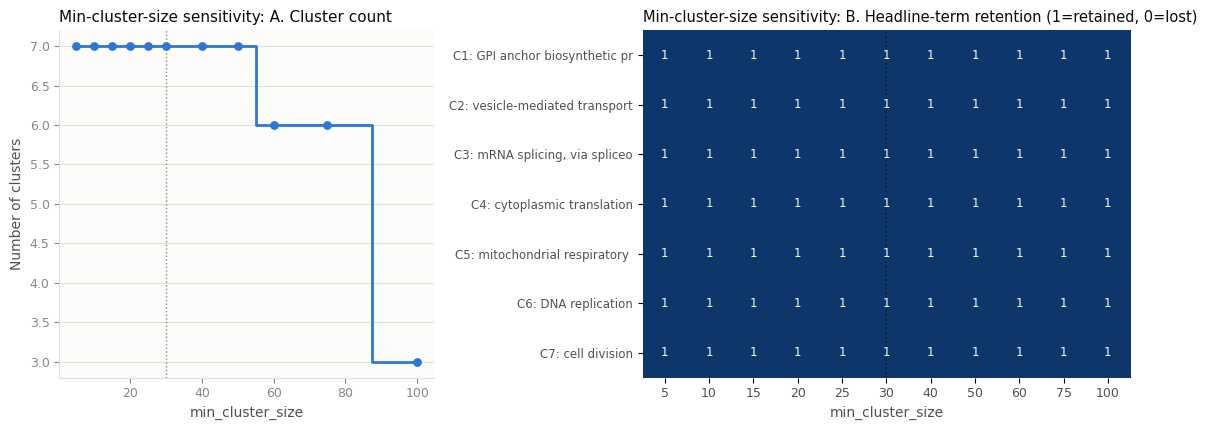

Saved /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/figures/11_depth_threshold_sensitivity/min_size_sensitivity.png


In [18]:
min_size_fig_path = make_sensitivity_figure(
    grid=MIN_SIZE_GRID,
    axis_col="min_cluster_size",
    summary_df=min_size_sensitivity_summary,
    cluster_raw_df=per_min_size_cluster_raw,
    reference_value=REFERENCE_MIN_SIZE,
    xlabel="min_cluster_size",
    title_prefix="Min-cluster-size sensitivity: ",
    out_path=NB_FIGURES_DIR / "min_size_sensitivity.png",
)

## 15. GO / CONDITIONAL GO / CONCERN decision

Decision rule (frozen plan Section 4), computed from the tables above, not asserted:

- **GO**: no reference cluster is knife-edge on either axis.
- **CONDITIONAL GO**: one or more clusters are knife-edge, but every merge-artifact outcome is `graceful_merge` (the headline term survives inside a consolidated cluster) -- claims hold within the recommended operating range, narrower claims needed outside it.
- **CONCERN**: any merge-artifact outcome is `vanished` (the term is lost outright), or knife-edge affects the majority of reference clusters.

In [19]:
n_clusters_total = len(reference_cluster_to_labels)
n_knife_edge = int(knife_edge_annotations["knife_edge_any_axis"].sum())
n_vanished = (
    int((merge_artifact_check["outcome"] == "vanished").sum())
    if not merge_artifact_check.empty
    else 0
)
n_graceful = (
    int((merge_artifact_check["outcome"] == "graceful_merge").sum())
    if not merge_artifact_check.empty
    else 0
)

print(f"Reference clusters: {n_clusters_total}")
print(f"Knife-edge (either axis): {n_knife_edge}")
print(f"Merge-artifact outcomes: graceful_merge={n_graceful}, vanished={n_vanished}")
if n_knife_edge == 0:
    print("No clusters were knife-edge on the tested neighboring settings.")

if n_knife_edge == 0:
    decision = "GO"
elif n_vanished == 0 and n_knife_edge <= n_clusters_total // 2:
    decision = "CONDITIONAL_GO"
else:
    decision = "CONCERN"

print(f"\nDECISION: {decision}")

Reference clusters: 7
Knife-edge (either axis): 0
Merge-artifact outcomes: graceful_merge=0, vanished=0
No clusters were knife-edge on the tested neighboring settings.

DECISION: GO


## 16. Assemble and write manifest

In [20]:
flags = list(input_hash_flags)
if activation is None:
    flags.append(f"HIMALAYAS ACTIVATION FAILED: {activation_error}")

knife_edge_clusters = knife_edge_annotations.loc[
    knife_edge_annotations["knife_edge_any_axis"], "ref_top_term"
].tolist()

if decision == "GO":
    next_action = (
        "Proceed to 20_annotation_permutation_null.ipynb. Claim: the submitted "
        f"threshold={REFERENCE_THRESHOLD}/min_cluster_size={REFERENCE_MIN_SIZE} settings are "
        "not knife-edge. Headline annotations hold across the full tested threshold band "
        f"[{threshold_range_all_stable[0]}, {threshold_range_all_stable[1]}] and "
        f"min_cluster_size band [{min_size_range_all_stable[0]}, {min_size_range_all_stable[1]}]; "
        "no annotation is knife-edge with respect to either setting. This is headline-term "
        "retention, not cluster-structure preservation -- cluster count itself changes across "
        "both bands (see the granularity note)."
    )
elif decision == "CONDITIONAL_GO":
    next_action = (
        "Proceed to 20_annotation_permutation_null.ipynb, but state the operating range "
        f"explicitly: threshold in [{threshold_range_all_stable[0]}, {threshold_range_all_stable[1]}], "
        f"min_cluster_size in [{min_size_range_all_stable[0]}, {min_size_range_all_stable[1]}] for all "
        f"{n_clusters_total} annotations; outside that range, {knife_edge_clusters} consolidate "
        "gracefully into a neighboring annotation rather than being lost (frozen plan Section 4)."
    )
else:
    next_action = (
        "PAUSE manuscript polish. At least one annotation is lost outright (not merely merged) "
        f"under a small threshold/min-size change ({n_vanished} vanished outcome(s) of "
        f"{n_knife_edge} knife-edge cluster(s)). Reconsider claims, figures, or venue before "
        "investing further time (frozen plan Section 4, No-Go response)."
    )

manifest = {
    "notebook": "11_depth_threshold_sensitivity.ipynb",
    "status": "COMPLETE" if activation is not None else "BLOCKED",
    "decision": decision,
    "next_action": next_action,
    "generated_at_utc": ru.utc_timestamp(),
    "repo_root": str(layout["repo_root"]),
    "himalayas_source": activation if activation is not None else {"error": activation_error},
    "himalayas_diagnostics_at_start": himalayas_diag_before,
    "input_files": {
        "gi_pcc_matrix": {
            "path": "data/yeast/gi_pcc_sampled.tsv",
            "sha256": current_hashes["data/yeast/gi_pcc_sampled.tsv"],
            "matches_nb00_record": current_hashes["data/yeast/gi_pcc_sampled.tsv"]
            == recorded_hashes.get("data/yeast/gi_pcc_sampled.tsv"),
        },
        "go_bp_annotations": {
            "path": "data/yeast/go_bp_name_to_orfs.json",
            "sha256": current_hashes["data/yeast/go_bp_name_to_orfs.json"],
            "matches_nb00_record": current_hashes["data/yeast/go_bp_name_to_orfs.json"]
            == recorded_hashes.get("data/yeast/go_bp_name_to_orfs.json"),
        },
    },
    "reference_config": {
        "linkage_method": LINKAGE_METHOD,
        "linkage_metric": LINKAGE_METRIC,
        "linkage_threshold": REFERENCE_THRESHOLD,
        "optimal_ordering": OPTIMAL_ORDERING,
        "min_cluster_size": REFERENCE_MIN_SIZE,
        "min_overlap": MIN_OVERLAP,
        "qval_cutoff": QVAL_CUTOFF,
    },
    "reference_reproduction_check": {
        "matches_nb01_nb10_baseline": bool(reproduction_matches),
        "results_rows": len(reference_results.df),
        "results_sig_rows": len(reference_results_sig.df),
        "n_clusters": len(reference_cluster_labels),
    },
    "merge_height_landscape": {
        "reference_threshold": REFERENCE_THRESHOLD,
        "prev_merge_below_reference": float(prev_merge_below_reference),
        "next_merge_above_reference": float(next_merge_above_reference),
        "margin_above_reference": float(next_merge_above_reference - REFERENCE_THRESHOLD),
    },
    "sweep_design": {
        "threshold_grid": THRESHOLD_GRID,
        "min_cluster_size_grid": MIN_SIZE_GRID,
        "knife_edge_neighbors": KNIFE_EDGE_NEIGHBORS,
    },
    "recommended_operating_range": {
        "threshold": list(threshold_range_all_stable),
        "min_cluster_size": list(min_size_range_all_stable),
    },
    "knife_edge_summary": {
        "n_clusters_total": n_clusters_total,
        "n_knife_edge": n_knife_edge,
        "n_merge_artifact_graceful": n_graceful,
        "n_merge_artifact_vanished": n_vanished,
        "knife_edge_cluster_terms": knife_edge_clusters,
    },
    "flags": flags,
    "outputs": {
        "tables": table_paths,
        "figures": {
            "threshold_sensitivity.png": str(threshold_fig_path.relative_to(layout["repo_root"])),
            "min_size_sensitivity.png": str(min_size_fig_path.relative_to(layout["repo_root"])),
        },
    },
    "interpretation": (
        f"Decision={decision}. Claim: the submitted threshold={REFERENCE_THRESHOLD}/"
        f"min_cluster_size={REFERENCE_MIN_SIZE} settings are not knife-edge. Recommended "
        f"operating range for all {n_clusters_total} reference-cluster headline annotations: "
        f"threshold in {list(threshold_range_all_stable)}, min_cluster_size in "
        f"{list(min_size_range_all_stable)} (reference well inside both bands). This range "
        "describes headline-term retention, not preserved cluster structure -- the number of "
        "clusters itself changes across the swept range (see the granularity note below). "
        + (
            "No clusters were knife-edge on the tested neighboring settings; "
            "merge_artifact_check.csv is empty because no knife-edge clusters required "
            "merge-artifact classification (see knife_edge_annotations.csv for the full "
            "per-annotation retention grid). "
            if n_knife_edge == 0
            else f"{n_knife_edge}/{n_clusters_total} clusters are knife-edge on at least one axis "
            f"({knife_edge_clusters}); of their merge events, {n_graceful} consolidate gracefully "
            f"(headline term remains significant in the merged cluster) and {n_vanished} vanish "
            "outright. See knife_edge_annotations.csv and merge_artifact_check.csv for the "
            "per-annotation breakdown. "
        )
        + "Coarser thresholds and high min_cluster_size settings preserved headline terms "
        "while reducing cluster granularity -- e.g. cluster count falls from 8 to 3 over the "
        "tested threshold range while retention stays at or near 100%. Prefer settings near "
        "the reference (threshold=16, min_cluster_size=30) when biological resolution "
        "matters, even though coarser settings remain statistically defensible."
    ),
}

manifest_path = layout["manifests_dir"] / f"{NB_ID}_manifest.json"
ru.write_manifest(manifest, manifest_path)
print(f"Manifest written to: {manifest_path}")

reloaded = json.loads(manifest_path.read_text())
assert reloaded == json.loads(json.dumps(manifest, default=str)), "manifest round-trip mismatch"
print("Manifest JSON round-trip verified.")

Manifest written to: /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/manifests/11_depth_threshold_sensitivity_manifest.json
Manifest JSON round-trip verified.


## 17. Readiness summary

In [21]:
print("=" * 72)
print(f"DECISION -- {NB_ID}")
print("=" * 72)
print(f"status:      {manifest['status']}")
print(f"decision:    {manifest['decision']}")
print(f"next_action: {manifest['next_action']}")
print()
print(
    f"HiMaLAYAS source: {activation['activated_version'] if activation else 'N/A'} "
    f"(verified tag {PINNED_TAG}, not the active dev install)"
)
print(f"Reference reproduction matches notebooks 01/10: {reproduction_matches}")
print()
print("Granularity note: coarser thresholds / higher min_cluster_size preserve headline")
print("annotations (terms stay significant inside consolidated clusters) but reduce cluster")
print("resolution -- see threshold_sensitivity_summary.csv / min_size_sensitivity_summary.csv")
print("for the cluster-count-vs-retention tradeoff.")
print()
print("Knife-edge annotations:")
display(
    knife_edge_annotations[
        [
            "ref_cluster_id",
            "ref_top_term",
            "knife_edge_threshold",
            "knife_edge_min_size",
            "knife_edge_any_axis",
        ]
    ]
)
if not merge_artifact_check.empty:
    print("\nMerge-artifact outcomes:")
    display(
        merge_artifact_check[
            [
                "ref_cluster_id",
                "ref_top_term",
                "axis",
                "boundary_value",
                "merged_cluster_top_term",
                "outcome",
            ]
        ]
    )
print()
print(f"Manifest:  {manifest_path}")
print(f"Tables:    {NB_TABLES_DIR}")
print(f"Figures:   {NB_FIGURES_DIR}")

DECISION -- 11_depth_threshold_sensitivity
status:      COMPLETE
decision:    GO
next_action: Proceed to 20_annotation_permutation_null.ipynb. Claim: the submitted threshold=16/min_cluster_size=30 settings are not knife-edge. Headline annotations hold across the full tested threshold band [15, 22] and min_cluster_size band [5, 100]; no annotation is knife-edge with respect to either setting. This is headline-term retention, not cluster-structure preservation -- cluster count itself changes across both bands (see the granularity note).

HiMaLAYAS source: 0.0.15 (verified tag v0.0.15, not the active dev install)
Reference reproduction matches notebooks 01/10: True

Granularity note: coarser thresholds / higher min_cluster_size preserve headline
annotations (terms stay significant inside consolidated clusters) but reduce cluster
resolution -- see threshold_sensitivity_summary.csv / min_size_sensitivity_summary.csv
for the cluster-count-vs-retention tradeoff.

Knife-edge annotations:


,ref_cluster_id,ref_top_term,knife_edge_threshold,knife_edge_min_size,knife_edge_any_axis
0,1,GPI anchor biosynthetic process,False,False,False
1,2,vesicle-mediated transport,False,False,False
2,3,"mRNA splicing, via spliceosome",False,False,False
3,4,cytoplasmic translation,False,False,False
4,5,mitochondrial respiratory chain complex IV ass...,False,False,False
5,6,DNA replication,False,False,False
6,7,cell division,False,False,False



Manifest:  /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/manifests/11_depth_threshold_sensitivity_manifest.json
Tables:    /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/tables/11_depth_threshold_sensitivity
Figures:   /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/figures/11_depth_threshold_sensitivity
